#### Loading training and validation datasets

Import libraries and set directories

In [35]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter # To count the number of occurrences of each label

# Locate the repository from the notebook working directory.
PROJECT_ROOT = next(
    (directory for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "scripts" / "build_processed_dataset.py").is_file()
     and (directory / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Start Jupyter from the repository root or a subdirectory.")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

train_path = PROCESSED_DATA_DIR / "nuscenes_train_prediction_samples.pkl"
val_path = PROCESSED_DATA_DIR / "nuscenes_val_prediction_samples.pkl"
test_path = PROCESSED_DATA_DIR / "nuscenes_test_prediction_samples.pkl"

# Load datasets
with open(train_path, "rb") as f: # rb = read binary
    train_dataset = pickle.load(f)
    
with open(val_path, "rb") as f: 
    val_dataset = pickle.load(f)
    
with open(test_path, "rb") as f:
    test_dataset = pickle.load(f)
    
print("Train samples: ",len(train_dataset))
print("Val samples: ",len(val_dataset))
print("Test samples: ",len(test_dataset))

Train samples:  25711
Val samples:  6685
Test samples:  7242


#### Constant velocity baseline

For each sample we estimate the velocity from the past target. Since data is at 0.5 s intervals (2 Hz) we compute velocity as $v$ and predict 
$p_t$ as: 

$$v = \frac{p_t - p_{t-1}}{0.5} \ \ \ \ \  \hat p_t = p_{0} + v \cdot t$$

for the next **12** steps starting from $p_0$ (current position).

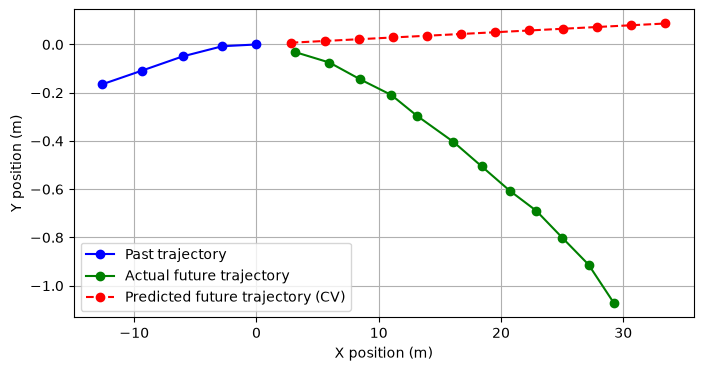

In [21]:
import numpy as np

def constant_velocity_prediction(target_past, future_steps=12, dt=0.5): 
    
    p_prev = target_past[-2] # get last 2s  
    p_current = target_past[-1] # 
    
    velocity = (p_current - p_prev) / dt  
    
    predictions = []
    
    for step in range(1, future_steps + 1):
        t = step * dt
        pred = p_current + velocity * t
        predictions.append(pred)
        
    return np.array(predictions)

sample = train_dataset[101]
y_past = sample['target_past']

# Compare y_hat and y
y_hat = constant_velocity_prediction(sample['target_past'])
y = sample['target_future']

plt.figure(figsize=(8, 4))
plt.plot(y_past[:, 0], y_past[:, 1], 'bo-', label='Past trajectory')
plt.plot(y[:, 0], y[:, 1], 'go-', label='Actual future trajectory')
plt.plot(y_hat[:, 0], y_hat[:, 1], 'ro--', label='Predicted future trajectory (CV)')
plt.xlabel('X position (m)'); plt.ylabel('Y position (m)')
plt.legend(); plt.grid()  

#### Benchmarking
For benchmarking, we compute the average displacement error (ADE) and final displacement error (FDE) for each sample in the validation set. 

```bash
- ADE will tell, on average, how far the predicted trajectory is from the ground truth trajectory.
```
```bash
- FDE tells how wrong the final 6s position is
```

\begin{equation}
ADE = \frac{1}{12} \sum_{t=1}^{12} \sqrt{(x_t - \hat{x}_t)^2 + (y_t - \hat{y}_t)^2}
\end{equation}


In [22]:
def compute_ade_fde(pred_future, target_future):
    pred_future = np.asarray(pred_future)
    target_future = np.asarray(target_future)
    errors = np.linalg.norm(pred_future - target_future, axis=1)
    return errors.mean(), errors[-1]

# Sample error
ade, fde = compute_ade_fde(y_hat, sample["target_future"])
# print("ADE:", ade)
# print("FDE:", fde)

# For all validation samples
cv_ade_list = []
cv_fde_list = []

for sample in val_dataset: 
    y_hat = constant_velocity_prediction(sample['target_past'])
    ade, fde = compute_ade_fde(y_hat, sample["target_future"])
    
    cv_ade_list.append(ade)
    cv_fde_list.append(fde)
    
# mean ADE and FDE
cv_ade_mean = np.mean(cv_ade_list)
cv_fde_mean = np.mean(cv_fde_list)

print("Validation samples:", len(val_dataset))
print("Constant Velocity Baseline - Mean ADE:", cv_ade_mean)
print("Constant Velocity Baseline - Mean FDE:", cv_fde_mean)    

Validation samples: 6685
Constant Velocity Baseline - Mean ADE: 4.772387
Constant Velocity Baseline - Mean FDE: 11.572312


#### Prepare data for GNN 

Check Notion page  [here](https://good-bluebell-9e8.notion.site/NuScenes-data-3e61be03c31580a5b85ce80655d3947c?source=copy_link) for more information about the data strucuture and how to prepare it for GNN training.

Target past shape: (5, 2)
Target future shape: (12, 2)
Number of neighbors: 8
Number of Nodes: 9
Neighbor 0: (5, 2) vehicle.truck
Neighbor 1: (5, 2) vehicle.car
Neighbor 2: (5, 2) vehicle.truck
Neighbor 3: (5, 2) vehicle.car
Neighbor 4: (5, 2) vehicle.truck
Neighbor 5: (5, 2) vehicle.car
Neighbor 6: (5, 2) vehicle.truck
Neighbor 7: (5, 2) vehicle.car
Metadata split: v1.0-trainval
Scene token: bebf5f5b2a674631ab5c88fd1aa9e87a
Camera images for this sample:
CAM_BACK: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_BACK/n008-2018-08-27-11-48-51-0400__CAM_BACK__1535385094387558.jpg (valid image)
CAM_BACK_LEFT: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_BACK_LEFT/n008-2018-08-27-11-48-51-0400__CAM_BACK_LEFT__1535385094297405.jpg (valid image)
CAM_BACK_RIGHT: /home/danilo/Desktop/gnn_trajectory/data/samples/CAM_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__CAM_BACK_RIGHT__1535385094528113.jpg (valid image)
CAM_FRONT: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_FRONT/n008-201

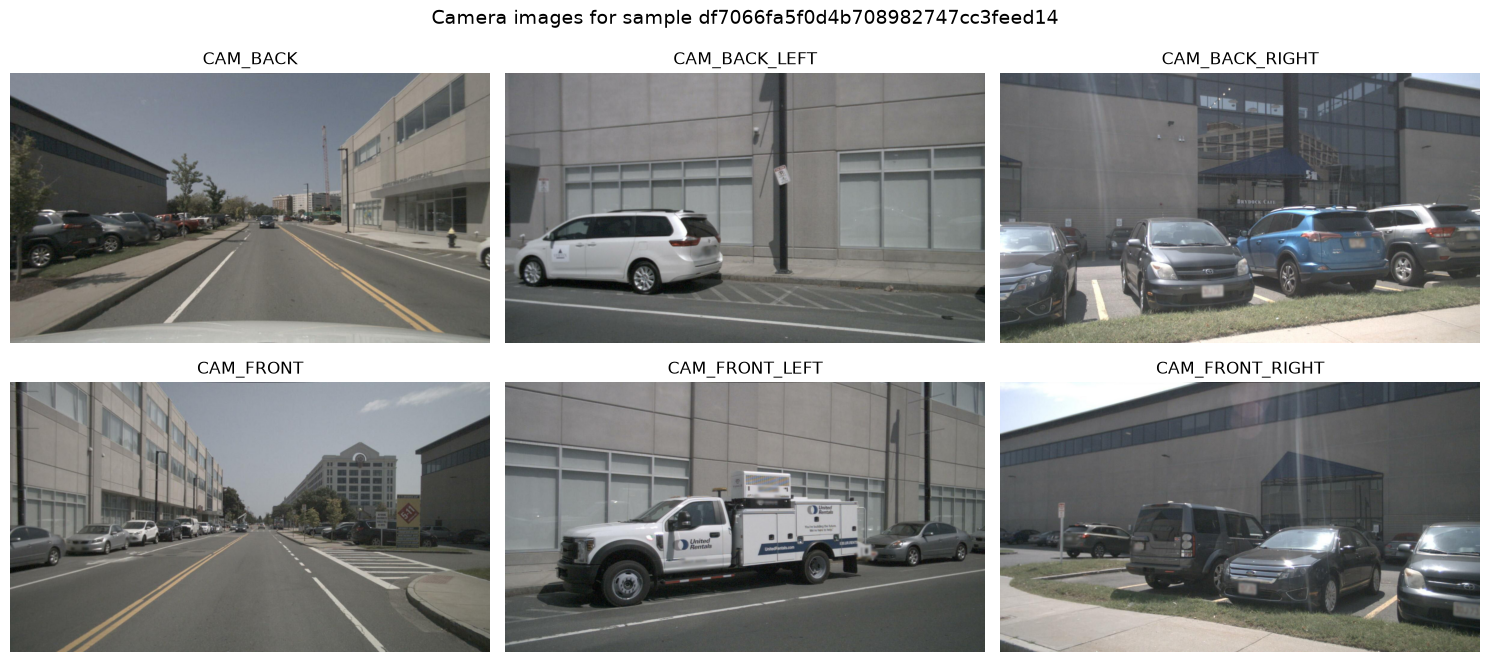

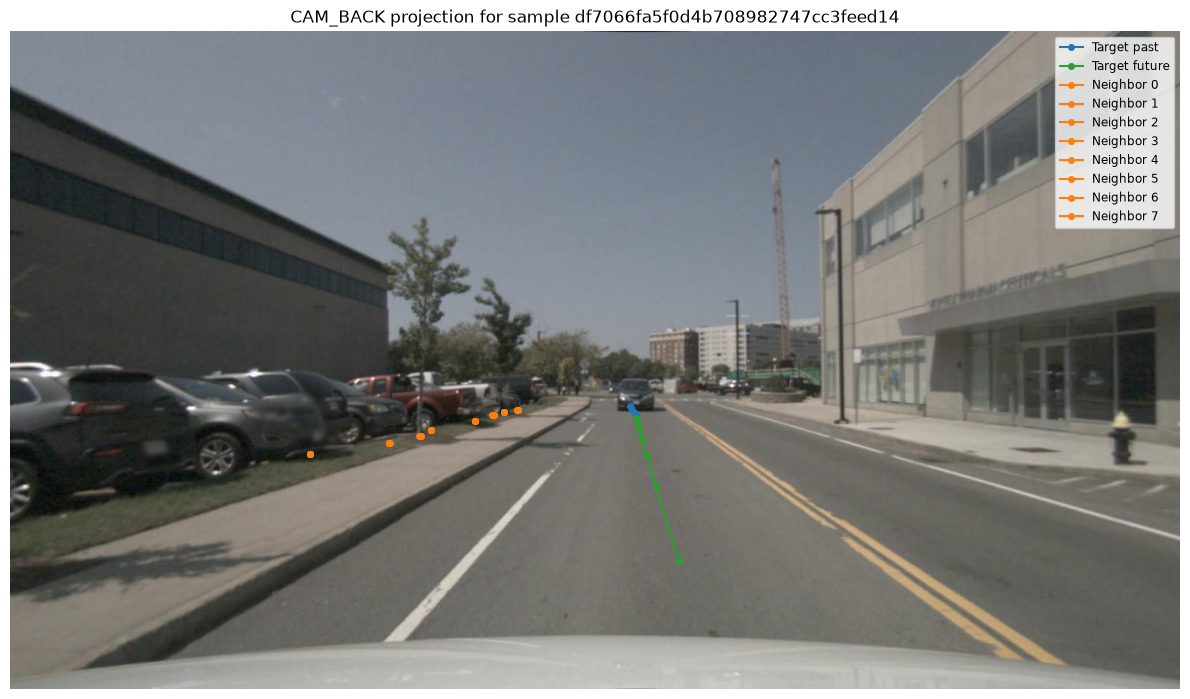

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'CAM_BACK projection for sample df7066fa5f0d4b708982747cc3feed14'}>)

In [23]:
sample = train_dataset[8842]

print("Target past shape:", sample["target_past"].shape)
print("Target future shape:", sample["target_future"].shape)
print("Number of neighbors:", len(sample["neighbors_pasts"]))
print("Number of Nodes:", len(sample["neighbors_pasts"]) + 1) # +1 for target node

for i, (past, category) in enumerate(zip(
    sample["neighbors_pasts"],sample["neighbors_categories"])):
    print(f"Neighbor {i}:",past.shape,category)
   

# Visualize all camera images and project onto the camera facing the target
import sys

sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from view_sample_image import view_sample_images
from project_sample_to_camera import plot_sample_camera_projection

view_sample_images(sample, DATA_DIR)
plot_sample_camera_projection(sample, DATA_DIR, channel="CAM_BACK")

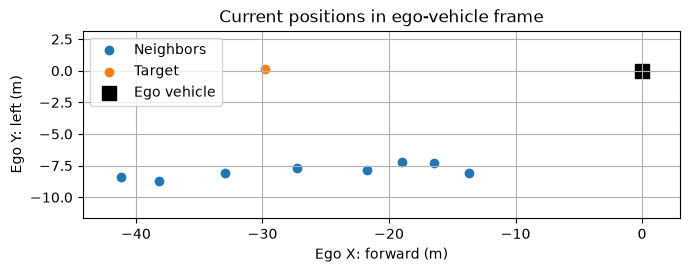

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'Current positions in ego-vehicle frame'}, xlabel='Ego X: forward (m)', ylabel='Ego Y: left (m)'>)

In [24]:
import sys
import importlib

sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import project_sample_to_camera
importlib.reload(project_sample_to_camera)

project_sample_to_camera.plot_sample_ego_frame(sample, DATA_DIR)

**Coordinate-frame note**: The nuScenes camera images are captured from the ego vehicle, i.e. the sensor-equipped data-collection car. The trajectory-prediction target is a separate annotated road user. Our trajectory plots are transformed into the target vehicle's local frame, where the target is located at \((0,0)\). Therefore, the origin of the trajectory plot does not correspond to the camera/ego vehicle. The same target may, for example, lie behind the ego vehicle and consequently appear in `CAM_BACK`

In [25]:
# TODO: Organize helper functions into a separate script for better modularity
import helper_functions
importlib.reload(helper_functions)
from helper_functions import general_category

# Category mapping
category_to_idx = {
    "car": 0,
    "large_vehicle": 1,
    "two_wheeler": 2,
    "pedestrian": 3,
    "other_vehicle": 4
}

# One-hot encoding function 
def category_one_hot(category):
    general = general_category(category)

    one_hot = np.zeros(5, dtype=np.float32)
    one_hot[category_to_idx[general]] = 1.0

    return one_hot

#### Verify node format for one sample
$x_i = [\text{trajectory}, \text {category}]$ where trajectory is a has N x (2 (x,y) coordinates) + 5 one hot encoded category vector. and N is the nº of Nodes in this sample

In [26]:
node_features = []


# TARGET = NODE 0
target_traj = sample["target_past"].flatten() # 10 elements  = (x_{t-4}, y_{t-4}, ..., x_{t}, y_{t}) 
target_one_hot = category_one_hot(sample["target_category"]) # -> one hot vector of length 5
target_features_vector = np.concatenate((target_traj, target_one_hot)) # 15 elements


node_features.append(target_features_vector) # with target node as the first element


# NEIGHBORS = NODES 1-4
for neighbor_past, category in zip(sample["neighbors_pasts"], sample["neighbors_categories"]): 
    
    neighbor_traj = neighbor_past.flatten() # 10 elements (x/y_{-4} to x/y_{5})
    neighbor_one_hot = category_one_hot(category) # -> one hot vector of length 5
    
    features = np.concatenate((neighbor_traj, neighbor_one_hot)) # 15 elements
    
    # Append to node_features list
    node_features.append(features)
    
# Stack all node features 
x = np.array(node_features, dtype=np.float32) # shape: (num_nodes, feature_dim = 15)

print("Node features array shape:", x.shape)
print(x) 

# 9 Nodes x 15 features = 135 elements in total for this sample

Node features array shape: (9, 15)
[[-14.022786    -0.25087366 -10.288019    -0.17162111  -6.85731
   -0.11481261  -3.047169    -0.05151617   0.           0.
    1.           0.           0.           0.           0.        ]
 [ -3.239977    -8.331206    -3.2375863   -8.294283    -3.2352705
   -8.259312    -3.2328424   -8.221414    -3.230596    -8.191448
    0.           1.           0.           0.           0.        ]
 [ 16.078722    -8.446189    16.078722    -8.446189    16.078722
   -8.446189    16.078722    -8.446189    16.078722    -8.446189
    1.           0.           0.           0.           0.        ]
 [ 13.225913    -7.6295037   13.249457    -7.614402    13.270037
   -7.600164    13.292604    -7.585025    13.31018     -7.5726876
    0.           1.           0.           0.           0.        ]
 [  2.429734    -7.870728     2.429734    -7.870728     2.429734
   -7.870728     2.429734    -7.870728     2.429734    -7.870728
    1.           0.           0.           0.   

In [27]:
print(f"\nx[0]: {x[0]}") # target node features 
print("\nTrajectory part:")
print(x[0][:10])
print("\nOne-hot category part:")
print(x[0][10:])


x[0]: [-14.022786    -0.25087366 -10.288019    -0.17162111  -6.85731
  -0.11481261  -3.047169    -0.05151617   0.           0.
   1.           0.           0.           0.           0.        ]

Trajectory part:
[-14.022786    -0.25087366 -10.288019    -0.17162111  -6.85731
  -0.11481261  -3.047169    -0.05151617   0.           0.        ]

One-hot category part:
[1. 0. 0. 0. 0.]


#### Add radius graph and edge index to node features list

For any two agents $i$ and $j$: 

$$(i,j) \in E \text{ if } ||p_i - p_j||_2 < r \rightarrow \text{edge index}$$

where $r$ is the radius threshold. We use $r=20$ m for our experiments.

In [ ]:
current_positions = x[:, 8:10]
edge_radius = 20.0  # meters

edges = []

num_nodes = len(current_positions) # 9

# Create edges based on the radius graph
for i in range(num_nodes):
  
    # loop through all nodes to check for neighbors
    for j in range(num_nodes): 
        
        # Check if the distance between nodes i and j is less than the edge_radius
        if i == j: 
            continue
        
        distance = np.linalg.norm(current_positions[i] - current_positions[j])
        
        # If the distance < 20 -> create an edge between nodes i and j
        if distance < edge_radius:
            edges.append([i, j])
            

edge_index = np.array(edges)
print(edge_index) # to visualize the connection better before transposing
edge_index = edge_index.T # shape: (2, num_edges)
print("Edge index shape:", edge_index.shape)

Here, each [i, j] represents a edge between two nodes. A lot of them have a connection with 0 i.e the target (vehicle.car) node. Note that the GNN will receive the transpose of this print so a (2x62)

In [29]:
print("edge_index shape:", edge_index.shape)
print("Number of directed edges:", edge_index.shape[1])

edge_index shape: (2, 62)
Number of directed edges: 62


#### Add edge_attributes to our node features list

Besides the index, we've decided to add to the edge features the relative position and also the distance between the two nodes so: 

$$\text{edge attributes} =[\Delta x, \Delta y, d]$$

where $\Delta x = x_i - x_j$, $\Delta y = y_i - y_j$ and $d = ||p_i - p_j||_2$.

In [30]:
edge_attributes = [] 

for source, target in edge_index.T: 
    source_pos = current_positions[source] # gives the (x, y) position of the source node
    target_pos = current_positions[target] # gives the (x, y) position of the target node
    
    delta_x = source_pos[0] - target_pos[0]
    delta_y = source_pos[1] - target_pos[1]
    
    distance = np.linalg.norm(source_pos - target_pos)
    
    edge_attributes.append([delta_x, delta_y, distance])
    
    edge_attributes_array = np.array(edge_attributes, dtype=np.float32) # shape: (num_edges, 3)
    
print("edge_attr shape:", edge_attributes_array.shape)

 # 62 edges x 3 features = 186 elements for this sample
 
 # Every [delta_x, delta_y, distance] <-> a edge_index column. 
for k in range(5):
    source, target = edge_index[:, k]

    print(
        f"{source} -> {target} | "
        f"edge_attr = {edge_attributes_array[k]}"
    )

edge_attr shape: (62, 3)
0 -> 1 | edge_attr = [3.230596 8.191448 8.805486]
0 -> 2 | edge_attr = [-16.078722   8.446189  18.162142]
0 -> 3 | edge_attr = [-13.31018     7.5726876  15.313604 ]
0 -> 4 | edge_attr = [-2.429734  7.870728  8.23723 ]
0 -> 5 | edge_attr = [ 8.487874  8.775824 12.208976]


Finish the edge $e$ with y, so the edge vector will be: 

$$e = [\Delta x, \Delta y, d]$$

In [31]:
# The target future positions for the nodes
y = np.array(sample["target_future"],
    dtype=np.float32)
 
# 12 future positions (x, y) for the target (ground truth)
print("Target future positions shape:", y.shape) 

Target future positions shape: (12, 2)


#### Wrap these into a PyTorch Geometric Data object

In [32]:
import torch
from torch_geometric.data import Data

graph = Data(
    x=torch.tensor(x, dtype=torch.float32),
    edge_index=torch.tensor(edge_index, dtype=torch.long),
    edge_attr=torch.tensor(edge_attributes_array, dtype=torch.float32),
    y=torch.tensor(y, dtype=torch.float32),
)   

print(graph)

/home/danilo/Desktop/gnn_trajectory/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Data(x=[9, 15], edge_index=[2, 62], edge_attr=[62, 3], y=[12, 2])


- 9 Agents (Nodes) 15 features each (x, y) coordinates for the past 6s + 5 one-hot encoded category vector

- 62 directed edges (connections) between the nodes, each with 3 features (Δx, Δy, d) 

- edge_att = [Δx, Δy, distance] vector for each edge

- y = [12, 2] future positions (x, y) for the target (ground truth)

NOW TURN EVERYTHING INTO A REUSABLE FUNCTION THAT TAKES A SAMPLE AND RETURNS A PYG DATA OBJECT



In [33]:
def sample_to_graph(sample, edge_radius=20.0):

    # ----------------------
    # BUILD NODE FEATURES
    # ----------------------

    node_features = []

    # Target = node 0
    target_traj = sample["target_past"].flatten()
    target_type = category_one_hot(sample["target_category"])

    target_features = np.concatenate((target_traj, target_type))

    node_features.append(target_features)

    # Neighbors = nodes 1, 2, ...
    for neighbor_past, category in zip(
        sample["neighbors_pasts"],
        sample["neighbors_categories"]):
        
        neighbor_traj = neighbor_past.flatten()
        neighbor_type = category_one_hot(category)
        features = np.concatenate((neighbor_traj, neighbor_type))

        node_features.append(features)

    # Features array of shape (num_nodes, feature_dim)
    x = np.array(node_features,dtype=np.float32)
    
    # ----------------------
    # TARGET NODE MASK
    # ----------------------

    target_mask = np.zeros(len(x), dtype=bool)
    target_mask[0] = True  # Mark the target node as True

    # ----------------------
    # CURRENT POSITIONS
    # ----------------------

    current_positions = x[:, 8:10]


    # ----------------------
    # BUILD EDGES
    # ----------------------

    edges = []

    num_nodes = len(current_positions)

    for i in range(num_nodes):
        for j in range(num_nodes):

            if i == j:
                continue

            distance = np.linalg.norm(current_positions[j] - current_positions[i])

            if distance < edge_radius:
                edges.append([i, j])

    # Handle graphs with no edges
    if len(edges) == 0:
        # If there are no edges, create an empty edge index
        edge_index = np.empty(
            (2, 0),
            dtype=np.int64
        )
    else:
        edge_index = np.array(
            edges,
            dtype=np.int64
        ).T


    # ----------------------
    # BUILD EDGE ATTRIBUTES
    # ----------------------

    edge_attributes = []

    for source, target in edge_index.T:

        source_pos = current_positions[source]
        target_pos = current_positions[target]

        delta = target_pos - source_pos

        delta_x = delta[0]
        delta_y = delta[1]
        distance = np.linalg.norm(delta)

        edge_attributes.append([delta_x, delta_y, distance])

    if len(edge_attributes) == 0:
        edge_attr = np.empty((0, 3),dtype=np.float32)
    else:
        edge_attr = np.array(edge_attributes,dtype=np.float32)


    # ----------------------
    # TARGET FUTURE
    # ----------------------

    y = np.array(
        sample["target_future"],
        dtype=np.float32
    )


    # ----------------------
    # PyG GRAPH
    # ----------------------

    graph = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float32),
        y=torch.tensor(y, dtype=torch.float32),
        target_mask=torch.tensor(target_mask, dtype=torch.bool)
    )

    return graph

# One sample test 
sample_to_graph(sample)

Data(x=[9, 15], edge_index=[2, 62], edge_attr=[62, 3], y=[12, 2], target_mask=[9])

#### Apply `sample_to_graph()` across the full train, validation and test processed datasets

In [42]:
from tqdm import tqdm # for progress bar

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}\n")

train_graphs = [sample_to_graph(sample) for sample in tqdm(train_dataset)]
val_graphs = [sample_to_graph(sample) for sample in tqdm(val_dataset)]
test_graphs = [sample_to_graph(sample) for sample in tqdm(test_dataset)]

print(f"\nNumber of training graphs: {len(train_graphs)}")
print(f"Number of validation graphs: {len(val_graphs)}")
print(f"Number of test graphs: {len(test_graphs)}")

Number of training samples: 25711
Number of validation samples: 6685
Number of test samples: 7242



100%|██████████| 7242/7242 [00:02<00:00, 3316.51it/s]


Number of training graphs: 25711
Number of validation graphs: 6685
Number of test graphs: 7242


In [43]:
# Output for many samples test
print(train_graphs[0])
print(train_graphs[1])
print(val_graphs[0])
print(val_graphs[1])
print(test_graphs[0])
print(test_graphs[1])

# Verify if there's any graph has zero edges
(train_graphs[25710].edge_index.shape) # n_cols = nª edges in this sample

zero_edge_train = []

for graph in train_graphs: 
    if graph.edge_index is None or graph.edge_index.numel() == 0:
        zero_edge_train.append(graph)

print(f"\nNumber of training graphs with zero edges: {len(zero_edge_train)}, out of {len(train_graphs)} total training graphs: {len(zero_edge_train)/len(train_graphs)*100:.2f}%")

zero_edge_val = []

for graph in val_graphs:
    if graph.edge_index is None or graph.edge_index.numel() == 0:
        zero_edge_val.append(graph)
        
zero_edge_test = []

for graph in test_graphs:
    if graph.edge_index is None or graph.edge_index.numel() == 0:
        zero_edge_test.append(graph)
        
print(f"Number of validation graphs with zero edges: {len(zero_edge_val)}, out of {len(val_graphs)} total validation graphs: {len(zero_edge_val)/len(val_graphs)*100:.2f}%")
print(f"Number of test graphs with zero edges: {len(zero_edge_test)}, out of {len(test_graphs)} total test graphs: {len(zero_edge_test)/len(test_graphs)*100:.2f}%")

Data(x=[9, 15], edge_index=[2, 62], edge_attr=[62, 3], y=[12, 2], target_mask=[9])
Data(x=[11, 15], edge_index=[2, 92], edge_attr=[92, 3], y=[12, 2], target_mask=[11])
Data(x=[1, 15], edge_index=[2, 0], edge_attr=[0, 3], y=[12, 2], target_mask=[1])
Data(x=[1, 15], edge_index=[2, 0], edge_attr=[0, 3], y=[12, 2], target_mask=[1])
Data(x=[9, 15], edge_index=[2, 44], edge_attr=[44, 3], y=[12, 2], target_mask=[9])
Data(x=[9, 15], edge_index=[2, 44], edge_attr=[44, 3], y=[12, 2], target_mask=[9])

Number of training graphs with zero edges: 3349, out of 25711 total training graphs: 13.03%
Number of validation graphs with zero edges: 572, out of 6685 total validation graphs: 8.56%
Number of test graphs with zero edges: 1050, out of 7242 total test graphs: 14.50%


13.03 % of the training samples have no edges, 8.56 % of the validation samples have no edges and 14.50 % of the test samples have no edges. This is because the target vehicle is alone in the scene and there are no other agents within the radius threshold of 20 m.

#### Create DataLoaders for training, validation and test datasets

In [44]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=64, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)


print(f"Number of batches in training DataLoader: {len(train_loader)}") # 402 batches with 64 element each
print(f"Number of batches in validation DataLoader: {len(val_loader)}")
print(f"Number of batches in test DataLoader: {len(test_loader)}")

batch = next(iter(train_loader)) # random sample of a batch from the training DataLoader

num_nodes_in_batch = batch.num_nodes

print(batch)

print("\nNumber of nodes in a batch:", num_nodes_in_batch) # x 15 features
print("Number of graphs in a batch:", batch.num_graphs)
print("Number of edges in a batch:", batch.num_edges) 

Number of batches in training DataLoader: 402
Number of batches in validation DataLoader: 105
Number of batches in test DataLoader: 114
DataBatch(x=[367, 15], edge_index=[2, 2220], edge_attr=[2220, 3], y=[768, 2], target_mask=[367], batch=[367], ptr=[65])

Number of nodes in a batch: 367
Number of graphs in a batch: 64
Number of edges in a batch: 2220


#### GNN Architecture 

Network architecture screenshot [here](../gnnArchitecure.pdf)


In [45]:
import torch
import torch.nn as nn
from torch_geometric.nn import GINEConv

class GraphNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # -------------------
        # ENCODER
        # -------------------
        self.encoder = nn.Sequential(
            nn.Linear(15, 64),
            nn.ReLU()
        )

        # -------------------
        # GINE 1
        # -------------------
        gine_mlp1 = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )

        self.gine1 = GINEConv(
            nn=gine_mlp1,
            edge_dim=3
        )

        # -------------------
        # GINE 2
        # -------------------
        gine_mlp2 = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )

        self.gine2 = GINEConv(
            nn=gine_mlp2,
            edge_dim=3
        )

        # -------------------
        # DECODER
        # -------------------
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 24)
        )

    def forward(self, batch):

        # X -> H^(0)
        h0 = self.encoder(batch.x)

        # H^(0) -> H^(1)
        h1 = self.gine1(
            h0,
            batch.edge_index,
            batch.edge_attr
        )
        
        # print("After GINE 1:", h1.shape)

        # H^(1) -> H^(2)
        h2 = self.gine2(
            h1,
            batch.edge_index,
            batch.edge_attr
        )

        # print("After GINE 2:", h2.shape)

        # Keep only prediction targets
        h_target = h2[batch.target_mask]

        # Decode future trajectory
        pred = self.decoder(h_target)

        # [batch_size, 24] -> [batch_size, 12, 2]
        pred = pred.view(-1, 12, 2)

        return pred
    
model = GraphNetwork() 
predictions = model(batch)

predictions.view(-1, 12, 2).shape # (batch_size, 12, 2)

torch.Size([64, 12, 2])

#### Training the GNN

We're going to use ADE (Average Displacement Error) as the loss function for training

Epoch 1/30 | Train ADE: 7.2016 m | Val ADE: 5.6294 m
Epoch 2/30 | Train ADE: 5.3911 m | Val ADE: 5.4809 m
Epoch 3/30 | Train ADE: 5.1235 m | Val ADE: 5.1173 m
Epoch 4/30 | Train ADE: 4.9940 m | Val ADE: 5.1611 m
Epoch 5/30 | Train ADE: 4.6973 m | Val ADE: 5.0126 m
Epoch 6/30 | Train ADE: 4.5993 m | Val ADE: 4.8425 m
Epoch 7/30 | Train ADE: 4.5540 m | Val ADE: 4.7844 m
Epoch 8/30 | Train ADE: 4.4943 m | Val ADE: 4.9623 m
Epoch 9/30 | Train ADE: 4.4776 m | Val ADE: 4.9351 m
Epoch 10/30 | Train ADE: 4.4009 m | Val ADE: 4.5515 m
Epoch 11/30 | Train ADE: 4.3364 m | Val ADE: 4.7560 m
Epoch 12/30 | Train ADE: 4.3112 m | Val ADE: 4.5841 m
Epoch 13/30 | Train ADE: 4.2514 m | Val ADE: 4.5990 m
Epoch 14/30 | Train ADE: 4.2128 m | Val ADE: 4.4388 m
Epoch 15/30 | Train ADE: 4.1784 m | Val ADE: 4.4741 m
Epoch 16/30 | Train ADE: 4.1416 m | Val ADE: 4.8734 m
Epoch 17/30 | Train ADE: 4.1157 m | Val ADE: 4.2701 m
Epoch 18/30 | Train ADE: 4.0866 m | Val ADE: 4.4731 m
Epoch 19/30 | Train ADE: 4.0532 m | V

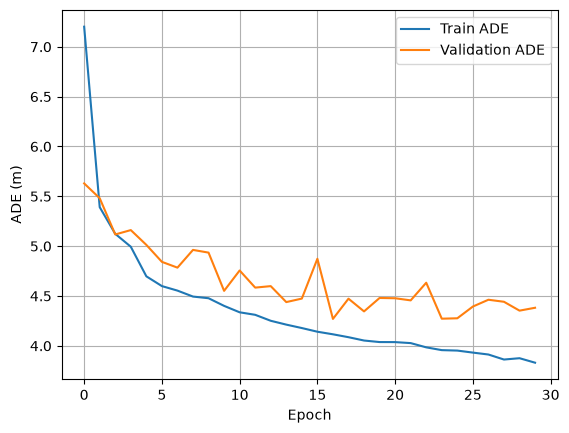

In [46]:
# ADE Loss function
def ade_loss(pred, target):
    errors = torch.norm(pred - target,dim=2)
    return errors.mean()

model = GraphNetwork() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = ade_loss
num_epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    total_loss = 0.0 # initialize total loss for the epoch

    for batch in train_loader:

        optimizer.zero_grad()
        pred = model(batch)
        target = batch.y.view(batch.num_graphs,12, 2)
        loss = loss_fn(pred, target)
        loss.backward()
        optimizer.step()

        total_loss += (loss.item() * batch.num_graphs)

    avg_loss = total_loss / len(train_graphs)

    train_losses.append(avg_loss)


    # VALIDATION
    model.eval()
    val_total_loss = 0.0 # initialize total loss for the validation set

    with torch.no_grad():

        for val_batch in val_loader:
            val_pred = model(val_batch)
            val_target = val_batch.y.view(val_batch.num_graphs, 12, 2)
            val_loss = loss_fn(val_pred, val_target)
            val_total_loss += (val_loss.item() * val_batch.num_graphs)

    val_avg_loss = (val_total_loss / len(val_graphs))

    val_losses.append(val_avg_loss)

    # OUTPUT
    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train ADE: {avg_loss:.4f} m | "
        f"Val ADE: {val_avg_loss:.4f} m"
    )

    # SAVE BEST MODEL
    if val_avg_loss < best_val_loss:
        best_val_loss = val_avg_loss
        torch.save(model.state_dict(), PROJECT_ROOT / "notebooks" / "best_gnn_model.pth")
    
# PLOT 
plt.plot(train_losses, label="Train ADE")
plt.plot(val_losses, label="Validation ADE")

plt.xlabel("Epoch")
plt.ylabel("ADE (m)")
plt.legend()
plt.grid()
plt.show()

Evaluate the best checkpoint on the full validation set and compute both ADE and FDE for the GNN benchmark

GNN Validation Results
Mean ADE: 3.906 m
Mean FDE: 9.126 m
